# Phase 5a: Logistic Regression Model (Imbalanced Data)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True})

print("Loading preprocessed dataset from Phase 2...")
df = pd.read_csv('../outputs/processed_imbalanced_data.csv')
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")

Loading preprocessed dataset from Phase 2...
Loaded 502,346 rows and 80 columns.


### Step 1: Train/Test Split

In [2]:
X = df.drop('Severity', axis=1)
y = df['Severity']

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]:,} rows.")
print(f"Testing set:  {X_test.shape[0]:,} rows.")

Training set: 401,876 rows.
Testing set:  100,470 rows.


### Train the Logistic Regression Model
We use `multi_class='multinomial'` to handle the 4 severity levels. `max_iter=1000` ensures the gradient descent algorithm converges on this large dataset.

In [3]:
print("Training Multinomial Logistic Regression Model on raw imbalanced data...")
log_model = LogisticRegression(multi_class='multinomial', max_iter=1000, n_jobs=-1, random_state=42)
log_model.fit(X_train, y_train)
print("Training Complete!")

Training Multinomial Logistic Regression Model on raw imbalanced data...
Training Complete!


### Evaluate on the UNTOUCHED Test Set

In [4]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)

print("--- Logistic Regression Evaluation Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")

--- Logistic Regression Evaluation Metrics ---
Accuracy:  0.7977
Precision: 0.7221
Recall:    0.7977
F1 Score:  0.7277


### Confusion Matrix

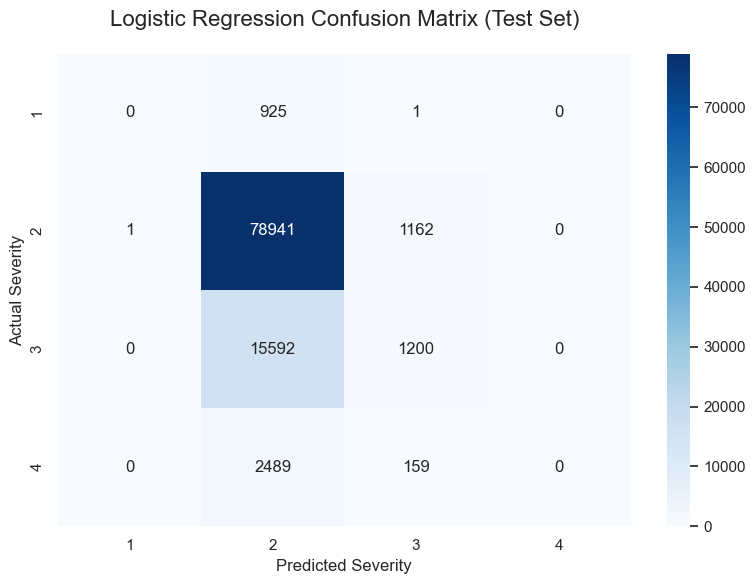

In [5]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4])
plt.title('Logistic Regression Confusion Matrix (Test Set)', fontsize=16, pad=20)
plt.ylabel('Actual Severity', fontsize=12)
plt.xlabel('Predicted Severity', fontsize=12)
plt.show()

### ROC Curve (Predicting Fatal Accidents)

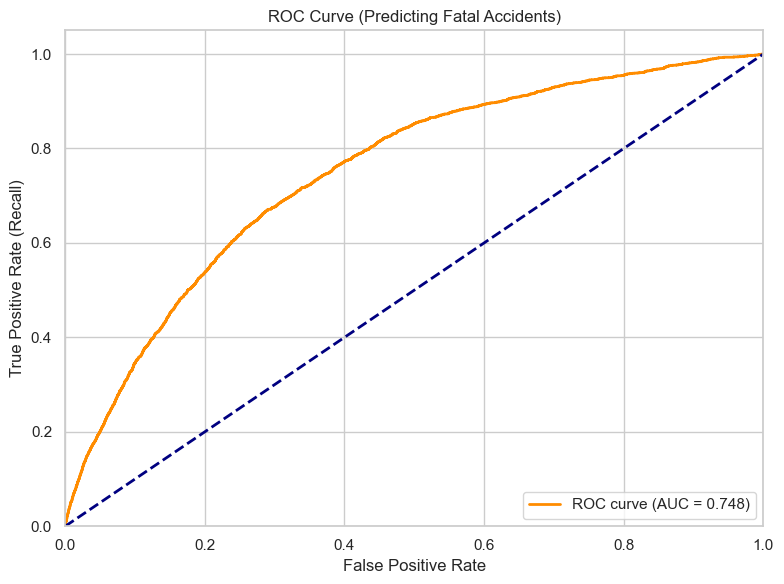

In [6]:
y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4])
fatal_class_idx = 3 # Index for Severity 4

fpr, tpr, _ = roc_curve(y_test_bin[:, fatal_class_idx], y_prob[:, fatal_class_idx])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve (Predicting Fatal Accidents)')
plt.legend(loc="lower right")
plt.show()

### Coefficient Weights for Fatal Accidents (Severity 4)
Logistic Regression assigns a 'weight' (coefficient) to every feature. Positive weights push the prediction TOWARD Fatal. Negative weights push it AWAY from Fatal.

/opt/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


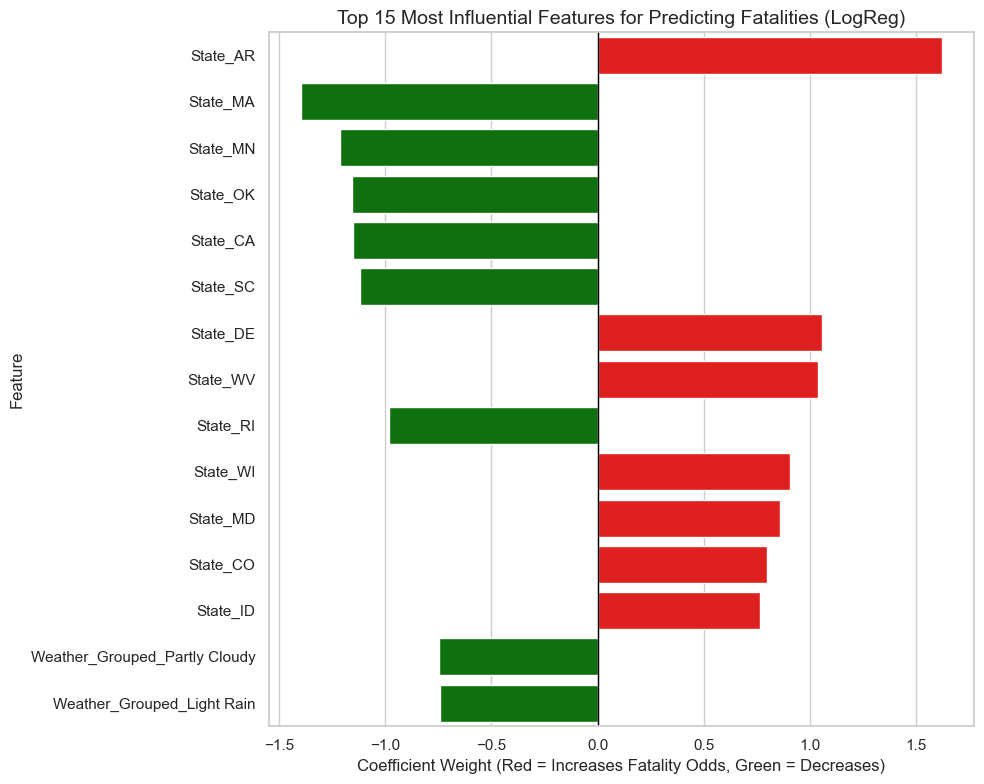

--- Odds Ratios (Top 5 Positive Drivers) ---
State_AR: odds increase by 5.06x
State_DE: odds increase by 2.87x
State_WV: odds increase by 2.82x
State_WI: odds increase by 2.48x
State_MD: odds increase by 2.36x
State_CO: odds increase by 2.22x
State_ID: odds increase by 2.15x


In [7]:
fatal_class_idx = 3 # Severity 4
weights = log_model.coef_[fatal_class_idx]
features = X.columns

# Get top 15 most influential features by absolute magnitude
top_indices = np.argsort(np.abs(weights))[::-1][:15]
top_weights = weights[top_indices]
top_features = [features[i] for i in top_indices]

plt.figure(figsize=(10, 8))
colors = ['red' if w > 0 else 'green' for w in top_weights]
sns.barplot(x=top_weights, y=top_features, palette=colors)
plt.title("Top 15 Most Influential Features for Predicting Fatalities (LogReg)", fontsize=14)
plt.xlabel("Coefficient Weight (Red = Increases Fatality Odds, Green = Decreases)")
plt.ylabel("Feature")
plt.axvline(0, color='black', linewidth=1)
plt.show()

print("--- Odds Ratios (Top 5 Positive Drivers) ---")
for f, w in zip(top_features, top_weights):
    if w > 0:
        print(f"{f}: odds increase by {np.exp(w):.2f}x")
